In [1]:
from keras.datasets import mnist # type: ignore
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

2026-05-06 20:06:08.206768: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 20:06:08.451922: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
print(f"The shape of train images are: {train_images.shape}")
print(f"The number of train labels are: {len(train_labels)}")
print("--" * 30)
print(f"The shape of test labels are: {len(test_labels)}")
test_labels

The shape of train images are: (60000, 28, 28)
The number of train labels are: 60000
------------------------------------------------------------
The shape of test labels are: 10000


array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

## Workflow
We feed the training data (train_images and train_labels) to the **Neural Network**. At this stage, the NN will try to associate the images and the labels. Then, we ask the NN to make predictions for test images, and we need to verify those predictions using test_labels.

In [4]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax")
    ]
)

#### Note:
Layer is the core building blocks of NN. It acts as a data filter. `Data --> Layer --> Data (useful form).`

The model above, consisted of the following:
- Two `Dense` layers, fully connected neural layers. 
- The second layer, is a 10-way softmax classification layer means that it will return an array of 10 probabilities scores (summing to 1). Each score representing the probability of current digit image, belongs to one of 10 digit classes.

**What is next?**

To make the model ready for training, we need to pick three more things, as part of compilation step:
1) _A loss function_, This is how the model will be able to measure its performance on the training data, and thus how it be able to steer itself on the right direction.
2) _An Opitmizer_, This is a mechanism of the model to update itself based on the training data it sees, this is done to improve its performance.
3) _Metrics to monitor during training and testing_, The accuracy, how many images that were correctly classified. 

In [5]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Preprocessing data
Before we train our model, we need to preprocess the data as the our model expected. We cannot feed the model with data that the model doed not expect. This is done by reshaping it into the shape that the model expect and scaling it so that all values are in the interval of [0, 1]. 
Previously, our training data were stored in an array of shape `[60000, 28, 28]` of type `uint8` with values in the `[0, 255]` interval. We will transform it into a `float32` array of shape (`60000, 28 8 28`) with values between 0 and 1.

In [6]:
train_images = train_images.reshape((60000, 28 * 28)) # reshaping
train_images = train_images.astype("float32") / 255 # scaling
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

The data is now ready for the model and we can just train our model with the preprocessed data. We can do it by using a call to the model's `fit()` method. 

In [7]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9247 - loss: 0.2667
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9685 - loss: 0.1091
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9792 - loss: 0.0712
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9857 - loss: 0.0498
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9897 - loss: 0.0369


#### Use the trained model for prediction
Our model has been trained. The accuracy is 0.9906 (99.06%) on the training data which is wow. Since we have our trained model, we can now use the model to predict class probabilities for new digits. 

In [8]:
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
predictions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


array([1.0512538e-06, 3.6335422e-07, 1.3841506e-05, 1.1000757e-03,
       1.4020247e-09, 6.5274094e-07, 2.2917478e-10, 9.9887413e-01,
       5.8094888e-06, 3.9769216e-06], dtype=float32)

Each number of index i in that array corresponds to the probability that digit image
test_digits[0] belong to class i.
This first test digit has the highest probability score (0.99999106, almost 1) at index
7, so according to our model, it must be a 7.

In [20]:
predictions[0].argmax()

7

In [21]:
predictions[0][7]

0.99978715

Check if the labels agree?


In [22]:
test_labels[0]

7

In [18]:
predictions[1]

array([2.3571848e-08, 7.0978681e-06, 9.9997580e-01, 1.3372930e-05,
       1.6259679e-12, 3.4135070e-07, 4.4610438e-08, 7.2260963e-13,
       3.2665839e-06, 3.0537024e-11], dtype=float32)

In [25]:
print(f"Model prediction for digit at index 1: {predictions[1].argmax()}")
print(f"Model prediction probability for index 1: {predictions[1][2]}")
print(f"Test label for digit at index 1: {test_labels[1]}")

Model prediction for digit at index 1: 2
Model prediction probability for index 1: 0.9999758005142212
Test label for digit at index 1: 2


**Evaluating model on new data**

In [11]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"test_acc: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9785 - loss: 0.0650
test_acc: 0.9785000085830688


# DATA REPRESENTATION IN NEURAL NETWORK
Tensors is used as the basic data structures in the current machine learning system. Tensor is data container, specifically numerical data. By that definition, tensor is a thing to store numbers. 

## Scalars (rank-0 tensors)
Scalar is a tensor that only contains one number. People say it differently, whether *scalar tensor*, *rank-0 tensor*, or *0D tensor*. In numpy, `float32` and `float64` is a scalar tensor or scalar array. A scalar tensor has 0 axis and the number of axes of a tensor is called rank. That is why scalar is called 0 rank because it has no axes. It only contains a single number. 

In [24]:
import numpy as np
x = np.array(12)
print(f"Example of scalar: {x}")
print()
print(f"Dimension of the scalar above: {x.ndim}") # checking the number of dimensions
print(x.shape)

Example of scalar: 12

Dimension of the scalar above: 0
()


## Vectors (rank-1 tensors)
Vector is an array of numbers. Here, array is an ordered collection of numbers. This type of data is called rank-1 tensors. This tensors is one level above scalars and for that, it has exactly one axis rather than 0. The following is a numpy vector:

In [23]:
x = np.array([12, 3, 6, 14, 7])
print(f"Example of vector: {x}")
print()
print(f"The dimension so of the vector above: {x.ndim}")
print(f"shape: {x.shape}")

Example of vector: [12  3  6 14  7]

The dimension so of the vector above: 1
shape: (5,)


## Matrices (rank-2 tensors)
If vector is an array of numbers, matrix is an array of vectors. It is one level above vector. That is why it is called rank-2 or 2D tensor. Unlike vector that has one axes, matrix has two. Think of it like rows and columns of a tabular data or just like table that has columns and rows. 

In [22]:
x = np.array([[5, 78, 2, 34, 0],
              [6, 79, 3, 35, 1],
              [7, 80, 4, 36, 2]])
print("Example of matrix: {x}")
print()
print(f"The number of dimensions of matrix above: {x.ndim}")
print(f"shape: {x.shape}")

Example of matrix: {x}

The number of dimensions of matrix above: 2
shape: (3, 5)


## Rank-3 Tensors and higher-rank tensors
Now, for rank > 2, just think of it as matrices that are packed together. We can visually think it as a cube of numbers. More than one matrices in one container. 

In [21]:
x3d = np.array([[[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]]])

print(f"Example of rank-3 tensor: {x3d}")
print()
print(f"The dimension of the tensor above is: {x3d.ndim}")
print(f"shape: {x3d.shape}")

Example of rank-3 tensor: [[[ 5 78  2 34  0]
  [ 6 79  3 35  1]
  [ 7 80  4 36  2]]

 [[ 5 78  2 34  0]
  [ 6 79  3 35  1]
  [ 7 80  4 36  2]]]

The dimension of the tensor above is: 3
shape: (2, 3, 5)


By looking at the pattern that form a tensor, we can now conclude that if we want to make rank-4 tensor, then we just need to pack the rank-3 tensor and so on. In general, we deal with 0-4 tensor in deep learning. It may go up to 5 if we process video data. 

In [26]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

2026-05-07 08:02:45.908922: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 08:02:46.150517: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.


In [27]:
train_images.ndim # Display the number of axes of the tensor train_images

3

In [28]:
train_images.shape # shape

(60000, 28, 28)

In [29]:
train_images.dtype # data types

dtype('uint8')

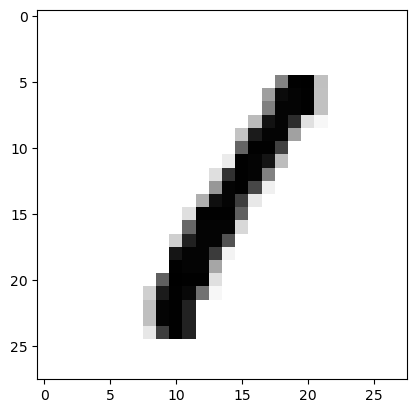

label: 1


In [33]:
import matplotlib.pyplot as plt

digit = train_images[3]
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()

print(f"label: {train_labels[3]}")

# MANIPULATING TENSOR IN NUMPY
#### 1) Slicing
Slicing is taking a certain part of our data. Think of it as we selecting our prefered elements of our data. 
```python
my_slice = train_images[10:100]
```
This selects images in the `train_images` from index 10 to 99, index 100 is not included.

In [35]:
my_slice = train_images[10:100]
my_slice.shape

(90, 28, 28)

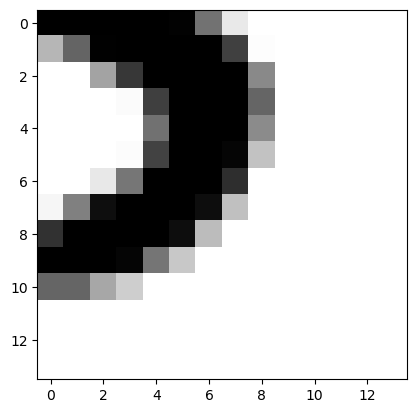

In [38]:
new_slice = train_images[10:15, 14:, 14:]
plt.imshow(new_slice[2], cmap=plt.cm.binary)

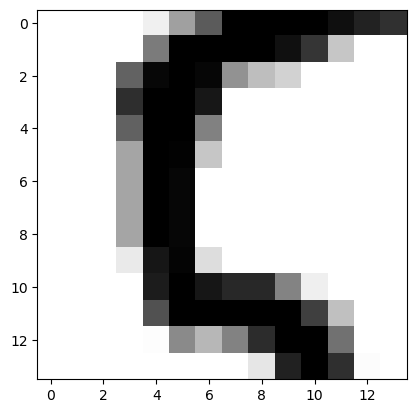

In [39]:
slices2 = train_images[100, 7:-7, 7:-7]
plt.imshow(slices2, cmap=plt.cm.binary)

### DATA BATCHES
Deep learning models do not process entire dataset at once, rather, we break data into small parts or we called it **batches**. It is a group of samples with a fixed size

In [40]:
batch1 = train_images[:128] # batch size 128

In [41]:
batch2 = train_images[128:256] # next 128 batch

In [42]:
n = 3 
batch = train_images[128 * n: 128 * (n + 1)]